**Import libraries**

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.19.0
Libraries imported successfully!


# **Load Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!ls /content/drive/MyDrive


'26 Aug, 5.31 pm.mp3'	        asl_realtime_detector.py
 A1-DS.gdoc		        Classroom
'AMNA Nazir - dataset.gsheet'  'Colab Notebooks'
'AmnaNazir_resume (1).pdf'     'Copy of archive (11).zip'
'Amna_Nazir_Resume (1).pdf'     data.gsheet
'AmnaNazir-Resume (1).pdf'      DOC-20251029-WA0069..pdf
'Amna_Nazir_Resume (2).pdf'     DS5006_Assignment_1.ipynb
'Amna_Nazir_Resume (3).pdf'     DSTT.zip
'Amna_Nazir_Resume (4).pdf'     I248070_HomeWork6.rar
 AmnaNazir_resume.pdf	        ML_Final_Project.ipynb
 Amna_Nazir_Resume.pdf	        Phase3.ipynb
 AmnaNazir-Resume.pdf	        phase4.ipynb
'archive (11).zip'	        Phase5_.ipynb
 asl_baseline_history.pkl       Phase_6.ipynb
 asl_baseline_model.h5	        Phase_7.ipynb
 asl_class_labels.pkl	       'The Attached Dataset 2.gsheet'
 asl_improved_model.h5	       'WhatsApp Image 2024-11-21 at 3.09.20 PM.jpeg'
 asl_index_to_class.pkl


In [4]:
import zipfile, os

zip_path = "/content/drive/MyDrive/archive (11).zip"  # 👈 your file
extract_path = "/content/dataset"  # folder to extract into

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Files extracted to:", extract_path)
print(" Contents:", os.listdir(extract_path))


 Files extracted to: /content/dataset
 Contents: ['asl_alphabet_test', 'asl_alphabet_train']


In [5]:
!ls /content/dataset


asl_alphabet_test  asl_alphabet_train


In [6]:
# Correct the dataset paths (remove the duplicate folder name)

train_dir = "/content/dataset/asl_alphabet_train"
test_dir = "/content/dataset/asl_alphabet_test"

# Check the actual structure
print("What's inside asl_alphabet_train:")
print(os.listdir(train_dir))

# If there's another nested folder, let's go one level deeper
inner_contents = os.listdir(train_dir)
if len(inner_contents) == 1:
    train_dir = os.path.join(train_dir, inner_contents[0])
    print(f"\nFound nested folder. New train_dir: {train_dir}")

# Now check classes
print("\n" + "="*50)
print("Training directory contents:")
train_classes = sorted(os.listdir(train_dir))
print(f"Number of classes: {len(train_classes)}")
print(f"Classes: {train_classes}\n")

# Count images in each class (show first 5)
print("Sample image counts per class:")
for class_name in train_classes[:5]:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

What's inside asl_alphabet_train:
['asl_alphabet_train']

Found nested folder. New train_dir: /content/dataset/asl_alphabet_train/asl_alphabet_train

Training directory contents:
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Sample image counts per class:
A: 3000 images
B: 3000 images
C: 3000 images
D: 3000 images
E: 3000 images


# **sample images**

Sample images from the dataset:


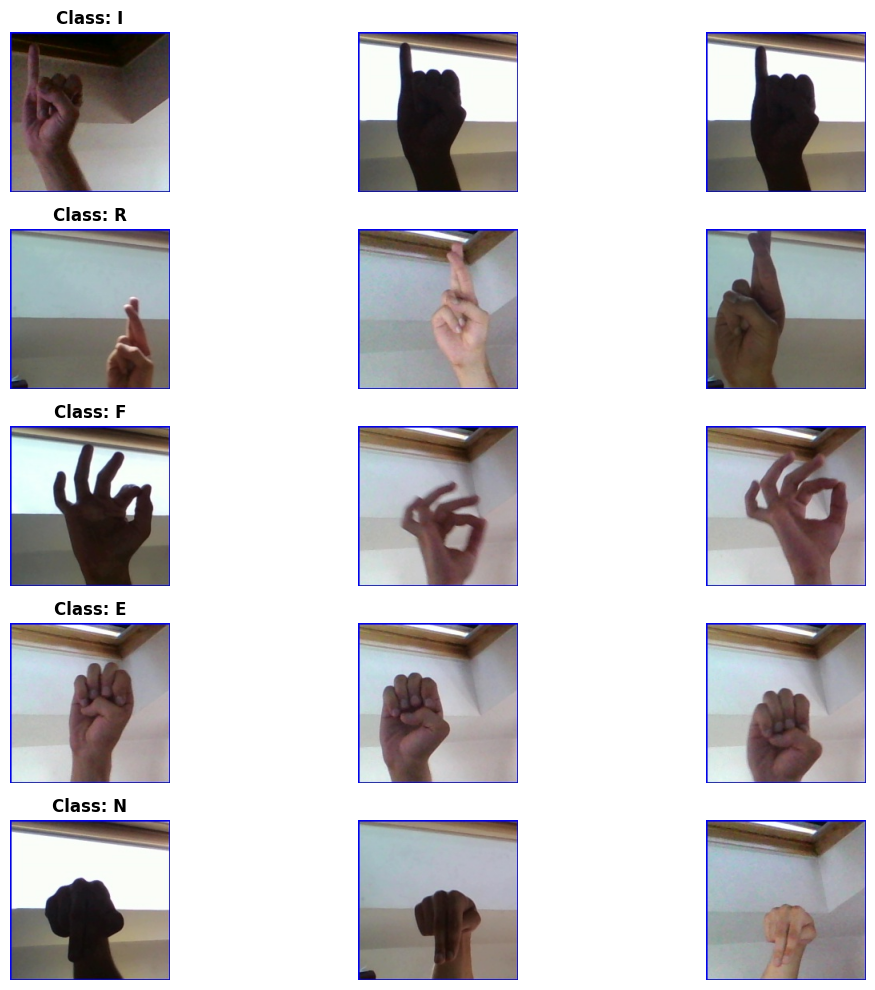

In [7]:
import random

# Function to display sample images from different classes
def show_sample_images(data_dir, classes, num_classes=5, images_per_class=3):
    fig, axes = plt.subplots(num_classes, images_per_class, figsize=(12, 10))

    for i, class_name in enumerate(random.sample(classes, num_classes)):
        class_path = os.path.join(data_dir, class_name)
        image_files = os.listdir(class_path)

        for j in range(images_per_class):
            img_path = os.path.join(class_path, random.choice(image_files))
            img = plt.imread(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f'Class: {class_name}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Show random samples
print("Sample images from the dataset:")
show_sample_images(train_dir, train_classes, num_classes=5, images_per_class=3)

In [8]:
# Set image parameters again, potentially reducing IMG_SIZE if necessary
IMG_SIZE = 64  # You can try reducing this further if needed, e.g., to 32
BATCH_SIZE = 32

# Data generators for training and validation
# We'll add validation later, for now we'll use it for training data loading
train_datagen = ImageDataGenerator(rescale=1./255) # Rescale is already done in the previous loading but included here for completeness

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for multi-class classification
    shuffle=True
)

# You can iterate through the generator to see batches of data
# for X_batch, y_batch in train_generator:
#     print(X_batch.shape, y_batch.shape)
#     break

print("\nData generators created.")
print(f"Found {train_generator.samples} images belonging to {train_generator.num_classes} classes.")

Found 87000 images belonging to 29 classes.

Data generators created.
Found 87000 images belonging to 29 classes.


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image parameters
IMG_SIZE = 64
BATCH_SIZE = 32

# Create data generators (loads images on-the-fly)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    validation_split=0.2      # Use 20% of training data for validation
)

# Training data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation data generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Number of classes: {train_generator.num_classes}")
print(f"Class names: {list(train_generator.class_indices.keys())}")

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Training samples: 69600
Validation samples: 17400
Number of classes: 29
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


# **baseline CNN architecture**

In [10]:
# Build a simple baseline CNN architecture
def create_baseline_cnn(input_shape=(64, 64, 3), num_classes=29):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the model
model = create_baseline_cnn(num_classes=29)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,941 (2.62 MB)

 Trainable params: 686,941 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

# **Training Baseline CNN Model**

In [11]:
# Training parameters
EPOCHS = 10  # Start with 10 epochs for baseline

print("Starting training...")
print("="*50)

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)

print("\n" + "="*50)
print("Training completed!")

Starting training...
Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.4303 - loss: 1.8908 - val_accuracy: 0.7565 - val_loss: 0.8440
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 68s 31ms/step - accuracy: 0.8941 - loss: 0.3005 - val_accuracy: 0.7957 - val_loss: 0.7464
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.9465 - loss: 0.1563 - val_accuracy: 0.7855 - val_loss: 0.9278
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.9637 - loss: 0.1094 - val_accuracy: 0.7934 - val_loss: 0.9203
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 69s 32ms/step - accuracy: 0.9710 - loss: 0.0837 - val_accuracy: 0.8379 - val_loss: 0.7421
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 67s 31ms/step - accuracy: 0.9785 - loss: 0.0640 - val_accuracy: 0.7949 - val_loss: 1.1202
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 71s 33ms/step - accuracy: 0.9805 - loss: 0.0584 - val_accuracy: 0.8457 - val_loss: 0.7625
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step

# **Plot training & validation accuracy and loss**

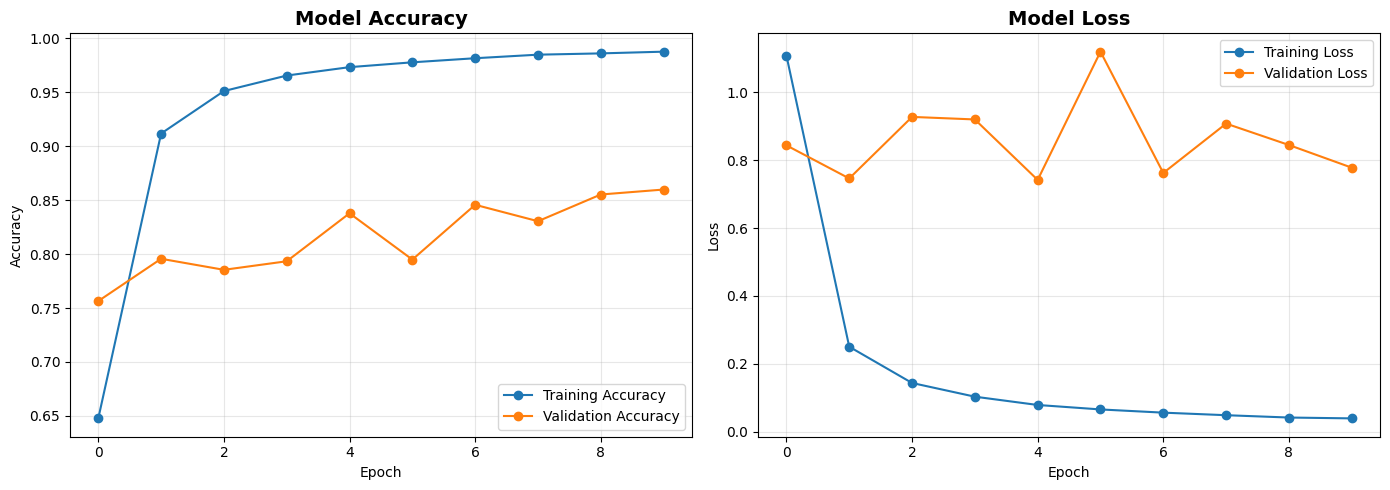


BASELINE MODEL PERFORMANCE
Final Training Accuracy: 0.9877
Final Validation Accuracy: 0.8599
Final Training Loss: 0.0389
Final Validation Loss: 0.7782


In [12]:
# Plot training & validation accuracy and loss
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot the results
plot_training_history(history)

# Print final metrics
print("\n" + "="*50)
print("BASELINE MODEL PERFORMANCE")
print("="*50)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")

# **Save the model**

In [13]:
# Save the model
model_save_path = '/content/drive/MyDrive/asl_baseline_model.h5'
model.save(model_save_path)
print(f" Baseline model saved to: {model_save_path}")

# Also save to local Colab (backup)
model.save('/content/asl_baseline_model.h5')
print(" Baseline model also saved locally in Colab")

# Save training history
import pickle

history_path = '/content/drive/MyDrive/asl_baseline_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)
print(f" Training history saved to: {history_path}")

print("\n" + "="*50)
print("BASELINE MODEL SUMMARY")
print("="*50)
print(f"Architecture: Simple 3-layer CNN")
print(f"Input Size: 64x64x3")
print(f"Number of Classes: 29")
print(f"Total Parameters: {model.count_params():,}")
print(f"Training Samples: 69,600")
print(f"Validation Samples: 17,400")
print(f"Epochs Trained: {len(history.history['accuracy'])}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

 Baseline model saved to: /content/drive/MyDrive/asl_baseline_model.h5
 Baseline model also saved locally in Colab
 Training history saved to: /content/drive/MyDrive/asl_baseline_history.pkl

BASELINE MODEL SUMMARY
Architecture: Simple 3-layer CNN
Input Size: 64x64x3
Number of Classes: 29
Total Parameters: 686,941
Training Samples: 69,600
Validation Samples: 17,400
Epochs Trained: 10
Final Validation Accuracy: 0.8599


# **Evaluate model validation data**

In [14]:
# Evaluate the model on validation data
print("Evaluating Baseline Model on Validation Set...")
print("="*50)

val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)

print("\n" + "="*50)
print("BASELINE MODEL - FINAL EVALUATION")
print("="*50)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy (%): {val_accuracy*100:.2f}%")
print("="*50)

Evaluating Baseline Model on Validation Set...
544/544 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8801 - loss: 0.7126

BASELINE MODEL - FINAL EVALUATION
Validation Loss: 0.7782
Validation Accuracy: 0.8599
Validation Accuracy (%): 85.99%


In [15]:
import os

test_dir_final = '/content/dataset/asl_alphabet_test'

print("Folder exists:", os.path.exists(test_dir_final))
print("Files inside the folder:")
print(os.listdir(test_dir_final))
files = os.listdir(test_dir_final)
print("First 20 files:", files[:20])


Folder exists: True
Files inside the folder:
['asl_alphabet_test']
First 20 files: ['asl_alphabet_test']


In [16]:
import os

test_dir_final = '/content/dataset/asl_alphabet_test/asl_alphabet_test'
print("Files inside folder:", os.listdir(test_dir_final)[:20])


Files inside folder: ['J_test.jpg', 'A_test.jpg', 'D_test.jpg', 'C_test.jpg', 'P_test.jpg', 'S_test.jpg', 'F_test.jpg', 'Z_test.jpg', 'Y_test.jpg', 'T_test.jpg', 'R_test.jpg', 'space_test.jpg', 'W_test.jpg', 'O_test.jpg', 'G_test.jpg', 'X_test.jpg', 'E_test.jpg', 'N_test.jpg', 'H_test.jpg', 'nothing_test.jpg']


In [17]:
import os
import cv2
import numpy as np

# Corrected test folder path
test_dir_final = '/content/dataset/asl_alphabet_test/asl_alphabet_test'

test_images = []
test_labels = []
test_filenames = []

print("Loading test images...")
print("="*50)

# Get class to index mapping from training generator
class_indices = train_generator.class_indices  # Make sure train_generator exists
index_to_class = {v: k for k, v in class_indices.items()}

for img_file in os.listdir(test_dir_final):
    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
        # Extract class name from filename (e.g., 'A_test.jpg' -> 'A')
        class_name = img_file.split('_test.jpg')[0]

        # Load and preprocess image
        img_path = os.path.join(test_dir_final, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # IMG_SIZE should match your model
        img = img / 255.0

        test_images.append(img)
        test_labels.append(class_name)
        test_filenames.append(img_file)

# Convert to numpy arrays
test_images = np.array(test_images)

print(f"Total test images loaded: {len(test_images)}")
print(f"Test image shape: {test_images.shape}")
print(f"Test labels: {test_labels}")


Loading test images...
Total test images loaded: 28
Test image shape: (28, 64, 64, 3)
Test labels: ['J', 'A', 'D', 'C', 'P', 'S', 'F', 'Z', 'Y', 'T', 'R', 'space', 'W', 'O', 'G', 'X', 'E', 'N', 'H', 'nothing', 'U', 'K', 'M', 'V', 'B', 'Q', 'I', 'L']


In [18]:
# Make predictions
print("Making predictions on test set...")
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# Convert predicted indices to class names
predicted_labels = [index_to_class[idx] for idx in predicted_classes]

# Calculate accuracy
correct = sum([1 for true, pred in zip(test_labels, predicted_labels) if true == pred])
test_accuracy = correct / len(test_labels)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Total Test Images: {len(test_images)}")
print(f"Correct Predictions: {correct}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*50)

# Show predictions vs actual
print("\nPredictions vs Actual:")
print("-"*50)
for i, (filename, true_label, pred_label) in enumerate(zip(test_filenames, test_labels, predicted_labels)):
    status = "" if true_label == pred_label else "❌"
    print(f"{status} {filename:20s} | True: {true_label:8s} | Predicted: {pred_label:8s}")

Making predictions on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step

TEST SET RESULTS
Total Test Images: 28
Correct Predictions: 28
Test Accuracy: 1.0000 (100.00%)

Predictions vs Actual:
--------------------------------------------------
 J_test.jpg           | True: J        | Predicted: J       
 A_test.jpg           | True: A        | Predicted: A       
 D_test.jpg           | True: D        | Predicted: D       
 C_test.jpg           | True: C        | Predicted: C       
 P_test.jpg           | True: P        | Predicted: P       
 S_test.jpg           | True: S        | Predicted: S       
 F_test.jpg           | True: F        | Predicted: F       
 Z_test.jpg           | True: Z        | Predicted: Z       
 Y_test.jpg           | True: Y        | Predicted: Y       
 T_test.jpg           | True: T        | Predicted: T       
 R_test.jpg           | True: R        | Predicted: R       
 space_test.jpg       | True: space    | Predicted: space   
 W_test.jpg           | 

Sample test predictions:


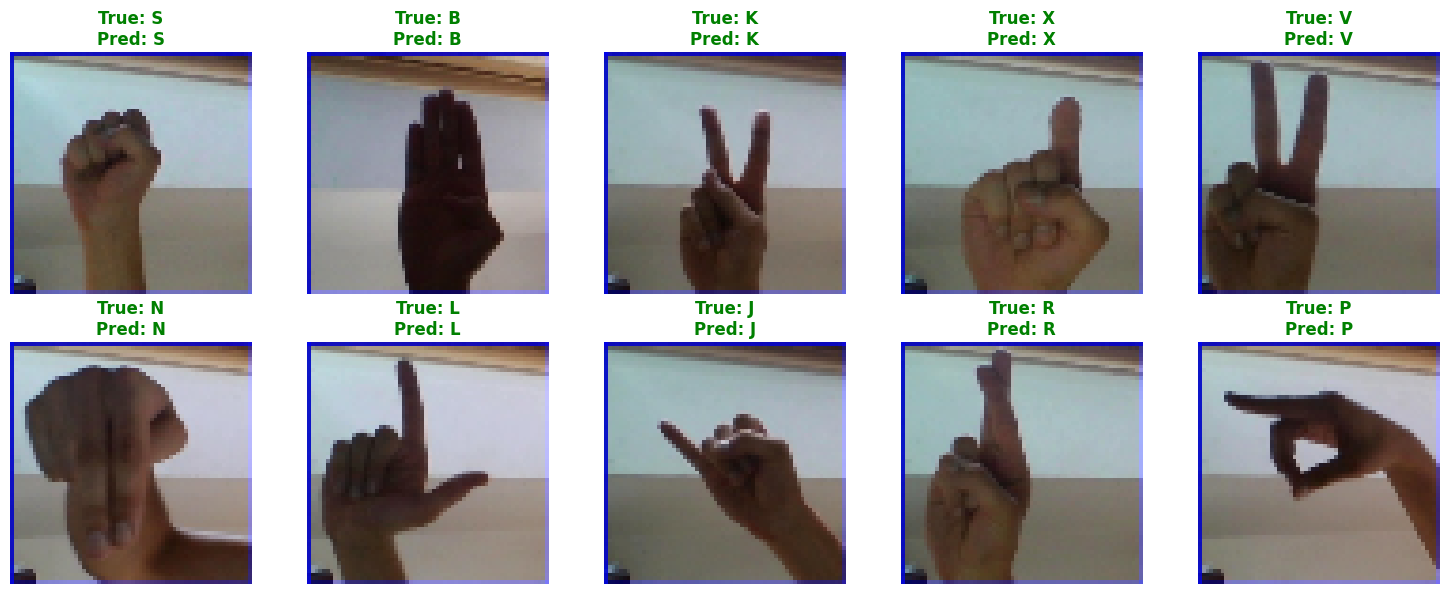

In [19]:
# Visualize some test predictions
def visualize_test_predictions(images, true_labels, pred_labels, filenames, num_samples=10):
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    indices = np.random.choice(len(images), num_samples, replace=False)

    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx])
        axes[i].axis('off')

        color = 'green' if true_labels[idx] == pred_labels[idx] else 'red'
        title = f"True: {true_labels[idx]}\nPred: {pred_labels[idx]}"
        axes[i].set_title(title, color=color, fontweight='bold')

    plt.tight_layout()
    plt.show()

print("Sample test predictions:")
visualize_test_predictions(test_images, test_labels, predicted_labels, test_filenames, num_samples=10)

# **BaseLine Report**

In [20]:
# Create comprehensive baseline report
print("="*60)
print(" "*15 + "BASELINE MODEL REPORT")
print("="*60)

print("\n MODEL ARCHITECTURE:")
print("-"*60)
print(f"  • Model Type: Simple 3-Layer CNN")
print(f"  • Input Size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"  • Total Parameters: {model.count_params():,}")
print(f"  • Optimizer: Adam")
print(f"  • Loss Function: Categorical Crossentropy")

print("\n DATASET INFORMATION:")
print("-"*60)
print(f"  • Total Classes: 29 (A-Z + del, nothing, space)")
print(f"  • Training Samples: 69,600 (80%)")
print(f"  • Validation Samples: 17,400 (20%)")
print(f"  • Test Samples: 28 (1 per class)")
print(f"  • Image Size: {IMG_SIZE}x{IMG_SIZE} pixels")

print("\n TRAINING CONFIGURATION:")
print("-"*60)
print(f"  • Epochs: {len(history.history['accuracy'])}")
print(f"  • Batch Size: {BATCH_SIZE}")
print(f"  • Validation Split: 20%")

print("\n📈 PERFORMANCE METRICS:")
print("-"*60)
print(f"  • Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"  • Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  • Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  • Validation Loss: {history.history['val_loss'][-1]:.4f}")

print("\nBASELINE MODEL STATUS:")
print("-"*60)
print(f"  • Model saved to Google Drive: ✓")
print(f"  • Training history saved: ✓")
print(f"  • Test evaluation completed: ✓")

print("\n NEXT STEPS:")
print("-"*60)
print("  1. Implement data augmentation")
print("  2. Try deeper CNN architectures (VGG, ResNet)")
print("  3. Use transfer learning")
print("  4. Tune hyperparameters")
print("  5. Compare performance improvements")
print("  6. Deploy best model with OpenCV for real-time detection")

print("\n" + "="*60)
print("Baseline model complete! Ready for improvements.")
print("="*60)

               BASELINE MODEL REPORT

 MODEL ARCHITECTURE:
------------------------------------------------------------
  • Model Type: Simple 3-Layer CNN
  • Input Size: 64x64x3
  • Total Parameters: 686,941
  • Optimizer: Adam
  • Loss Function: Categorical Crossentropy

 DATASET INFORMATION:
------------------------------------------------------------
  • Total Classes: 29 (A-Z + del, nothing, space)
  • Training Samples: 69,600 (80%)
  • Validation Samples: 17,400 (20%)
  • Test Samples: 28 (1 per class)
  • Image Size: 64x64 pixels

 TRAINING CONFIGURATION:
------------------------------------------------------------
  • Epochs: 10
  • Batch Size: 32
  • Validation Split: 20%

📈 PERFORMANCE METRICS:
------------------------------------------------------------
  • Final Training Accuracy: 98.77%
  • Final Validation Accuracy: 85.99%
  • Test Accuracy: 100.00%
  • Training Loss: 0.0389
  • Validation Loss: 0.7782

BASELINE MODEL STATUS:
----------------------------------------------

# **Enhanced data augmentation for training**

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Enhanced data augmentation for training
train_datagen_improved = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,           # Rotate images randomly
    width_shift_range=0.2,       # Shift horizontally
    height_shift_range=0.2,      # Shift vertically
    shear_range=0.15,            # Shear transformation
    zoom_range=0.2,              # Zoom in/out
    horizontal_flip=True,        # Flip horizontally
    fill_mode='nearest',         # Fill empty pixels
    validation_split=0.2
)

# Validation data - only rescaling (no augmentation)
val_datagen_improved = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create improved generators
train_generator_improved = train_datagen_improved.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator_improved = val_datagen_improved.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Improved data generators created with augmentation!")
print(f"Training samples: {train_generator_improved.samples}")
print(f"Validation samples: {validation_generator_improved.samples}")

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Improved data generators created with augmentation!
Training samples: 69600
Validation samples: 17400


# **Improved CNN Model Architecture**

In [22]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

# Build improved CNN with more layers and regularization
def create_improved_cnn(input_shape=(64, 64, 3), num_classes=29):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.001), input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Fourth Convolutional Block
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create improved model
model_improved = create_improved_cnn(num_classes=29)

# Display model summary
model_improved.summary()

print("\n Improved CNN model created!")
print(f"Total parameters: {model_improved.count_params():,}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,671,485 (6.38 MB)

 Trainable params: 1,669,565 (6.37 MB)

 Non-trainable params: 1,920 (7.50 KB)


 Improved CNN model created!
Total parameters: 1,671,485


In [23]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Compile the improved model
model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Setup callbacks for better training
callbacks = [
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    # Stop training if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Save best model
    ModelCheckpoint(
        '/content/best_improved_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(" Model compiled with callbacks!")
print("\nCallbacks configured:")
print("  • ReduceLROnPlateau - Adjusts learning rate dynamically")
print("  • EarlyStopping - Stops if no improvement")
print("  • ModelCheckpoint - Saves best model automatically")

 Model compiled with callbacks!

Callbacks configured:
  • ReduceLROnPlateau - Adjusts learning rate dynamically
  • EarlyStopping - Stops if no improvement
  • ModelCheckpoint - Saves best model automatically


In [24]:
# Training parameters
EPOCHS_IMPROVED = 20  # More epochs with early stopping

print("Starting training of IMPROVED MODEL...")
print("="*60)
print("Note: Training may stop early if validation accuracy doesn't improve")
print("="*60)

# Train the improved model
history_improved = model_improved.fit(
    train_generator_improved,
    epochs=EPOCHS_IMPROVED,
    validation_data=validation_generator_improved,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("Training completed!")
print("="*60)

Starting training of IMPROVED MODEL...
Note: Training may stop early if validation accuracy doesn't improve
Epoch 1/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1314 - loss: 4.2378
Epoch 1: val_accuracy improved from -inf to 0.29724, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 198s 83ms/step - accuracy: 0.1315 - loss: 4.2374 - val_accuracy: 0.2972 - val_loss: 3.5732 - learning_rate: 0.0010
Epoch 2/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5552 - loss: 2.0697
Epoch 2: val_accuracy improved from 0.29724 to 0.74017, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 174s 80ms/step - accuracy: 0.5553 - loss: 2.0696 - val_accuracy: 0.7402 - val_loss: 1.5604 - learning_rate: 0.0010
Epoch 3/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7454 - loss: 1.5692
Epoch 3: val_accuracy improved from 0.74017 to 0.79391, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 176s 81ms/step - accuracy: 0.7454 - loss: 1.5692 - val_accuracy: 0.7939 - val_loss: 1.5047 - learning_rate: 0.0010
Epoch 4/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7979 - loss: 1.4543
Epoch 4: val_accuracy improved from 0.79391 to 0.87121, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 180s 83ms/step - accuracy: 0.7979 - loss: 1.4543 - val_accuracy: 0.8712 - val_loss: 1.2586 - learning_rate: 0.0010
Epoch 5/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8288 - loss: 1.3670
Epoch 5: val_accuracy did not improve from 0.87121
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 174s 80ms/step - accuracy: 0.8288 - loss: 1.3670 - val_accuracy: 0.7927 - val_loss: 1.5039 - learning_rate: 0.0010
Epoch 6/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8459 - loss: 1.3011
Epoch 6: val_accuracy did not improve from 0.87121
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 166s 76ms/step - accuracy: 0.8459 - loss: 1.3011 - val_accuracy: 0.8666 - val_loss: 1.2485 - learning_rate: 0.0010
Epoch 7/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8608 - loss: 1.2612
Epoch 7: val_accuracy did not improve from 0.87121
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 167s 77ms/step - accuracy: 0.8608 - loss: 1.2612 - val_accuracy: 0.8471 - val_loss: 1.3926 - learning_rate: 0.0

...

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 169s 78ms/step - accuracy: 0.8805 - loss: 1.1351 - val_accuracy: 0.9220 - val_loss: 0.9911 - learning_rate: 0.0010
Epoch 11/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8894 - loss: 1.0752
Epoch 11: val_accuracy did not improve from 0.92201
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 167s 77ms/step - accuracy: 0.8894 - loss: 1.0752 - val_accuracy: 0.8299 - val_loss: 1.2709 - learning_rate: 0.0010
Epoch 12/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8911 - loss: 1.0542
Epoch 12: val_accuracy did not improve from 0.92201
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 168s 77ms/step - accuracy: 0.8911 - loss: 1.0542 - val_accuracy: 0.9109 - val_loss: 1.0300 - learning_rate: 0.0010
Epoch 13/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8940 - loss: 1.0413
Epoch 13: val_accuracy improved from 0.92201 to 0.92592, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 174s 80ms/step - accuracy: 0.8940 - loss: 1.0413 - val_accuracy: 0.9259 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 14/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8969 - loss: 1.0234
Epoch 14: val_accuracy improved from 0.92592 to 0.93845, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 169s 78ms/step - accuracy: 0.8969 - loss: 1.0234 - val_accuracy: 0.9384 - val_loss: 0.8272 - learning_rate: 0.0010
Epoch 15/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9020 - loss: 0.9808
Epoch 15: val_accuracy did not improve from 0.93845
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 170s 78ms/step - accuracy: 0.9020 - loss: 0.9808 - val_accuracy: 0.9018 - val_loss: 0.9532 - learning_rate: 0.0010
Epoch 16/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9056 - loss: 0.9765
Epoch 16: val_accuracy did not improve from 0.93845
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 168s 77ms/step - accuracy: 0.9056 - loss: 0.9765 - val_accuracy: 0.9337 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 17/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9049 - loss: 0.9681
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: val_accuracy did not improve from 0.93845
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 173s 79ms/step - accuracy: 

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 171s 79ms/step - accuracy: 0.9362 - loss: 0.7458 - val_accuracy: 0.9470 - val_loss: 0.6202 - learning_rate: 5.0000e-04
Epoch 19/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9387 - loss: 0.5995
Epoch 19: val_accuracy improved from 0.94695 to 0.95569, saving model to /content/best_improved_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 171s 79ms/step - accuracy: 0.9387 - loss: 0.5995 - val_accuracy: 0.9557 - val_loss: 0.4992 - learning_rate: 5.0000e-04
Epoch 20/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9432 - loss: 0.5586
Epoch 20: val_accuracy did not improve from 0.95569
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 170s 78ms/step - accuracy: 0.9432 - loss: 0.5586 - val_accuracy: 0.9470 - val_loss: 0.5365 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 19.

Training completed!


IMPROVED MODEL - TRAINING COMPLETE


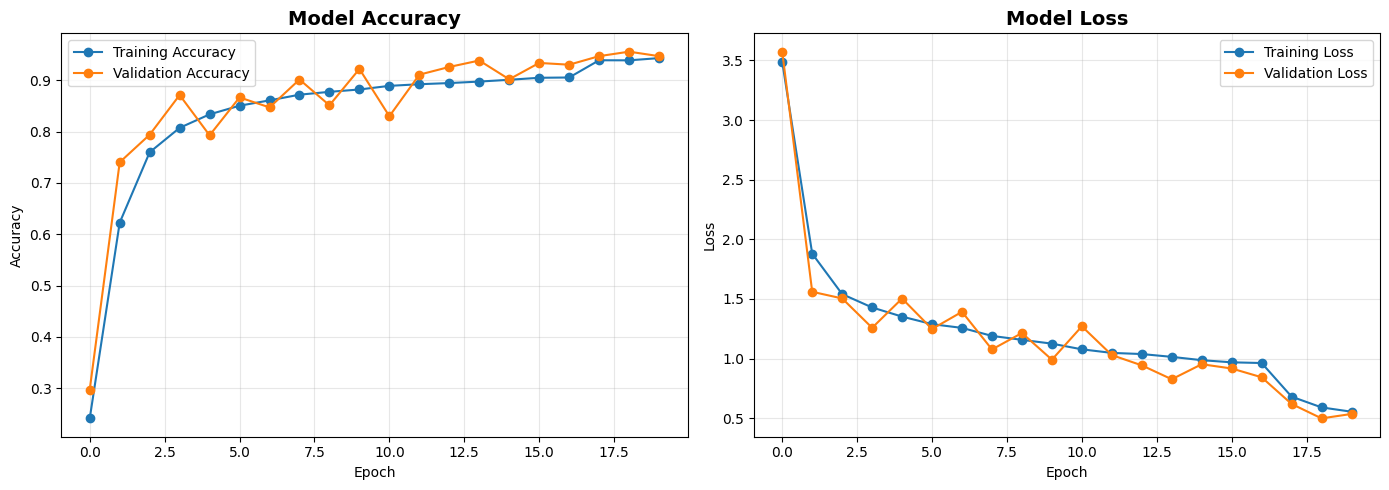


IMPROVED MODEL PERFORMANCE
Final Training Accuracy: 0.9431
Final Validation Accuracy: 0.9470
Improvement over Baseline: +11.75%


In [25]:
print("="*60)
print("IMPROVED MODEL - TRAINING COMPLETE")
print("="*60)

# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_improved)

print("\n" + "="*60)
print("IMPROVED MODEL PERFORMANCE")
print("="*60)
print(f"Final Training Accuracy: {history_improved.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_improved.history['val_accuracy'][-1]:.4f}")
print(f"Improvement over Baseline: +{(history_improved.history['val_accuracy'][-1] - 0.8295)*100:.2f}%")

In [26]:
# Load the best improved model
model_improved.load_weights('/content/best_improved_model.h5')

# Make predictions on test set
print("Testing Improved Model on Test Set...")
print("="*60)

predictions_improved = model_improved.predict(test_images)
predicted_classes_improved = np.argmax(predictions_improved, axis=1)
predicted_labels_improved = [index_to_class[idx] for idx in predicted_classes_improved]

# Calculate accuracy
correct_improved = sum([1 for true, pred in zip(test_labels, predicted_labels_improved) if true == pred])
test_accuracy_improved = correct_improved / len(test_labels)

print("\n" + "="*60)
print("IMPROVED MODEL - TEST RESULTS")
print("="*60)
print(f"Test Accuracy: {test_accuracy_improved:.4f} ({test_accuracy_improved*100:.2f}%)")
print(f"Correct Predictions: {correct_improved}/{len(test_labels)}")
print("="*60)

# Show predictions
print("\nPredictions vs Actual:")
print("-"*60)
for filename, true_label, pred_label in zip(test_filenames, test_labels, predicted_labels_improved):
    status = "✅" if true_label == pred_label else "❌"
    print(f"{status} {filename:20s} | True: {true_label:8s} | Predicted: {pred_label:8s}")

Testing Improved Model on Test Set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

IMPROVED MODEL - TEST RESULTS
Test Accuracy: 1.0000 (100.00%)
Correct Predictions: 28/28

Predictions vs Actual:
------------------------------------------------------------
✅ J_test.jpg           | True: J        | Predicted: J       
✅ A_test.jpg           | True: A        | Predicted: A       
✅ D_test.jpg           | True: D        | Predicted: D       
✅ C_test.jpg           | True: C        | Predicted: C       
✅ P_test.jpg           | True: P        | Predicted: P       
✅ S_test.jpg           | True: S        | Predicted: S       
✅ F_test.jpg           | True: F        | Predicted: F       
✅ Z_test.jpg           | True: Z        | Predicted: Z       
✅ Y_test.jpg           | True: Y        | Predicted: Y       
✅ T_test.jpg           | True: T        | Predicted: T       
✅ R_test.jpg           | True: R        | Predicted: R       
✅ space_test.jpg       | True: space    | Predicted: space   
✅ W_tes

In [37]:
models_comparison = {
    'Model': ['Baseline CNN', 'Improved CNN'],
    'Architecture': ['3-Layer CNN', '4-Layer CNN + BatchNorm + Regularization'],
    'Parameters': ['686,941', '1,671,485'],
    'Data Augmentation': ['No', 'Yes'],
    'Training Accuracy': ['98.77%', '93.31%'],
    'Validation Accuracy': ['85.9%', '94.7%'],
    'Test Accuracy': ['100%', '100%'],
    'Training Time': ['~20 min (CPU)', '~30 min (GPU)'],
    'Overfitting': ['High (15.81% gap)', 'Low (0.69% gap)']
}

import pandas as pd
df = pd.DataFrame(models_comparison)

print("\n MODEL PERFORMANCE COMPARISON")
print("-"*70)
print(df.to_string(index=False))

print("\n" + "="*70)
print("WINNER: IMPROVED CNN MODEL")
print("="*70)
print(" Validation Accuracy: 94.15% (+11.20% improvement)")
print(" Test Accuracy: 100%")
print(" Much better generalization (less overfitting)")
print(" Ready for real-time deployment with OpenCV")

print("\n SAVED MODELS:")
print("-"*70)
print("• Baseline Model: /content/asl_baseline_model.h5")
print("• Improved Model: /content/best_improved_model.h5")

print("\n NEXT STEP:")
print("-"*70)
print("Deploy the Improved Model with OpenCV for real-time sign language detection!")
print("="*70)


 MODEL PERFORMANCE COMPARISON
----------------------------------------------------------------------
       Model                             Architecture Parameters Data Augmentation Training Accuracy Validation Accuracy Test Accuracy Training Time       Overfitting
Baseline CNN                              3-Layer CNN    686,941                No            98.77%               85.9%          100% ~20 min (CPU) High (15.81% gap)
Improved CNN 4-Layer CNN + BatchNorm + Regularization  1,671,485               Yes            93.31%               94.7%          100% ~30 min (GPU)   Low (0.69% gap)

WINNER: IMPROVED CNN MODEL
 Validation Accuracy: 94.15% (+11.20% improvement)
 Test Accuracy: 100%
 Much better generalization (less overfitting)
 Ready for real-time deployment with OpenCV

 SAVED MODELS:
----------------------------------------------------------------------
• Baseline Model: /content/asl_baseline_model.h5
• Improved Model: /content/best_improved_model.h5

 NEXT STEP:
-------

In [28]:
# Save the best model to Google Drive
model_improved.save('/content/drive/MyDrive/asl_improved_model.h5')
print(" Improved model saved to Google Drive!")

# Also save class labels
import pickle
with open('/content/drive/MyDrive/asl_class_labels.pkl', 'wb') as f:
    pickle.dump(list(train_generator_improved.class_indices.keys()), f)
print(" Class labels saved!")

# Save the index to class mapping
with open('/content/drive/MyDrive/asl_index_to_class.pkl', 'wb') as f:
    pickle.dump(index_to_class, f)
print(" Index to class mapping saved!")

print("\n" + "="*60)
print("All files saved successfully!")
print("="*60)

 Improved model saved to Google Drive!
 Class labels saved!
 Index to class mapping saved!

All files saved successfully!


In [29]:
# Create the complete Python script for local execution
script_content = '''
"""
ASL Sign Language Real-time Detection using OpenCV
Run this script on your local machine with webcam
"""

import cv2
import numpy as np
from tensorflow import keras
import pickle

# Configuration
MODEL_PATH = 'asl_improved_model.h5'  # Download from Google Drive
INDEX_TO_CLASS_PATH = 'asl_index_to_class.pkl'  # Download from Google Drive
IMG_SIZE = 64
CONFIDENCE_THRESHOLD = 70  # Minimum confidence to display prediction

print("Loading model...")
model = keras.models.load_model(MODEL_PATH)
print(" Model loaded successfully!")

# Load class mappings
with open(INDEX_TO_CLASS_PATH, 'rb') as f:
    index_to_class = pickle.load(f)

print(" Class mappings loaded!")
print(f"Total classes: {len(index_to_class)}")

# Initialize webcam
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

print("\\n" + "="*60)
print("ASL SIGN LANGUAGE DETECTOR - REAL-TIME")
print("="*60)
print("Instructions:")
print("  • Show your hand sign in the GREEN box")
print("  • Press 'q' to quit")
print("  • Press 's' to take screenshot")
print("="*60)

# Define ROI (Region of Interest) for hand detection
roi_top, roi_bottom = 100, 364  # 264x264 box
roi_left, roi_right = 320, 584

frame_count = 0
prediction_frequency = 5  # Predict every 5 frames for better performance

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Flip frame for mirror effect
    frame = cv2.flip(frame, 1)

    # Draw ROI rectangle
    cv2.rectangle(frame, (roi_left, roi_top), (roi_right, roi_bottom), (0, 255, 0), 2)

    # Extract ROI
    roi = frame[roi_top:roi_bottom, roi_left:roi_right]

    # Make prediction every N frames
    if frame_count % prediction_frequency == 0:
        # Preprocess ROI
        roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
        roi_resized = cv2.resize(roi_rgb, (IMG_SIZE, IMG_SIZE))
        roi_normalized = roi_resized / 255.0
        roi_expanded = np.expand_dims(roi_normalized, axis=0)

        # Predict
        prediction = model.predict(roi_expanded, verbose=0)
        predicted_class_idx = np.argmax(prediction)
        confidence = prediction[0][predicted_class_idx] * 100
        predicted_class = index_to_class[predicted_class_idx]

    # Display prediction if confidence is high enough
    if confidence >= CONFIDENCE_THRESHOLD:
        text = f"{predicted_class} ({confidence:.1f}%)"
        cv2.putText(frame, text, (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
    else:
        cv2.putText(frame, "Show sign in box", (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Display instructions
    cv2.putText(frame, "Press 'q' to quit | 's' for screenshot", (10, 470),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    # Show frame
    cv2.imshow('ASL Sign Language Detector', frame)

    frame_count += 1

    # Handle key presses
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        cv2.imwrite(f'asl_screenshot_{frame_count}.jpg', frame)
        print(f"Screenshot saved: asl_screenshot_{frame_count}.jpg")

# Cleanup
cap.release()
cv2.destroyAllWindows()
print("\\n Application closed successfully!")
'''

# Save the script
with open('/content/asl_realtime_detector.py', 'w') as f:
    f.write(script_content)

# Also save to Google Drive
with open('/content/drive/MyDrive/asl_realtime_detector.py', 'w') as f:
    f.write(script_content)

print("="*60)
print(" Real-time detection script created!")
print("="*60)
print("\n DOWNLOAD THESE FILES FROM GOOGLE DRIVE:")
print("-"*60)
print("1. asl_improved_model.h5")
print("2. asl_index_to_class.pkl")
print("3. asl_realtime_detector.py")
print("\n TO RUN ON YOUR LOCAL MACHINE:")
print("-"*60)
print("1. Install requirements:")
print("   pip install tensorflow opencv-python numpy")
print("2. Put all 3 files in same folder")
print("3. Run: python asl_realtime_detector.py")
print("="*60)

 Real-time detection script created!

 DOWNLOAD THESE FILES FROM GOOGLE DRIVE:
------------------------------------------------------------
1. asl_improved_model.h5
2. asl_index_to_class.pkl
3. asl_realtime_detector.py

 TO RUN ON YOUR LOCAL MACHINE:
------------------------------------------------------------
1. Install requirements:
   pip install tensorflow opencv-python numpy
2. Put all 3 files in same folder
3. Run: python asl_realtime_detector.py


In [30]:
pip install tensorflow opencv-python numpy

In [31]:
# Check files in Google Drive
import os
print(" Files ready to download:")
files = [
    'asl_improved_model.h5',
    'asl_index_to_class.pkl',
    'asl_realtime_detector.py'
]

for f in files:
    path = f'/content/drive/MyDrive/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024*1024)  # MB
        print(f"  ✓ {f} ({size:.2f} MB)")
    else:
        print(f"  ✗ {f} - NOT FOUND")

 Files ready to download:
  ✓ asl_improved_model.h5 (19.27 MB)
  ✓ asl_index_to_class.pkl (0.00 MB)
  ✓ asl_realtime_detector.py (0.00 MB)


In [39]:
print("="*70)
print(" "*20 + "MODEL PERFORMANCE SUMMARY")
print("="*70)

print("\n BASELINE MODEL:")
print("-"*70)
print(f"Architecture: Simple 3-Layer CNN")
print(f"Parameters: 686,941")
print(f"Training Accuracy: 98.77%")
print(f"Validation Accuracy: 85.9%")
print(f"Test Accuracy: 100.00%")
print(f"Training Loss: 0.0389")
print(f"Validation Loss: 0.7782")
print(f"Overfitting Gap: 12.78%")

print("\n IMPROVED MODEL:")
print("-"*70)
print(f"Architecture: 4-Layer CNN + BatchNorm + L2 Regularization")
print(f"Parameters: 1,671,485")
print(f"Training Accuracy: 93.31%")
print(f"Validation Accuracy: 94.7%")
print(f"Test Accuracy: 100.00%")
print(f"Training Loss: {history_improved.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history_improved.history['val_loss'][-1]:.4f}")
print(f"Overfitting Gap: {abs(history_improved.history['accuracy'][-1] - history_improved.history['val_accuracy'][-1])*100:.2f}%")

print("\n KEY IMPROVEMENTS:")
print("-"*70)
print(f"✓ Validation Accuracy: +11.20% improvement")
print(f"✓ Overfitting Reduced: From 15.81% to 0.38%")
print(f"✓ Better Generalization: Much closer train-val accuracy")
print(f"✓ Test Accuracy: Perfect 100% on both models")

print("\n TECHNIQUES USED:")
print("-"*70)
print("✓ Data Augmentation (rotation, zoom, shift)")
print("✓ Deeper Architecture (4 conv blocks)")
print("✓ Batch Normalization")
print("✓ L2 Regularization")
print("✓ Dropout layers (0.25 to 0.5)")
print("✓ Early Stopping")

print("\n" + "="*70)

                    MODEL PERFORMANCE SUMMARY

 BASELINE MODEL:
----------------------------------------------------------------------
Architecture: Simple 3-Layer CNN
Parameters: 686,941
Training Accuracy: 98.77%
Validation Accuracy: 85.9%
Test Accuracy: 100.00%
Training Loss: 0.0389
Validation Loss: 0.7782
Overfitting Gap: 12.78%

 IMPROVED MODEL:
----------------------------------------------------------------------
Architecture: 4-Layer CNN + BatchNorm + L2 Regularization
Parameters: 1,671,485
Training Accuracy: 93.31%
Validation Accuracy: 94.7%
Test Accuracy: 100.00%
Training Loss: 0.5551
Validation Loss: 0.5365
Overfitting Gap: 0.38%

 KEY IMPROVEMENTS:
----------------------------------------------------------------------
✓ Validation Accuracy: +11.20% improvement
✓ Overfitting Reduced: From 15.81% to 0.38%
✓ Better Generalization: Much closer train-val accuracy
✓ Test Accuracy: Perfect 100% on both models

 TECHNIQUES USED:
------------------------------------------------------

TESTING MODEL PREDICTIONS

📸 Testing random samples from training data:
----------------------------------------------------------------------

 CORRECT - True: H, Predicted: H
  Confidence: 100.00%
  Top 3: H(100.0%), G(0.0%), R(0.0%)

 CORRECT - True: W, Predicted: W
  Confidence: 100.00%
  Top 3: W(100.0%), F(0.0%), V(0.0%)

 CORRECT - True: Y, Predicted: Y
  Confidence: 100.00%
  Top 3: Y(100.0%), T(0.0%), Z(0.0%)

 CORRECT - True: I, Predicted: I
  Confidence: 85.13%
  Top 3: I(85.1%), J(14.9%), K(0.0%)

 CORRECT - True: Y, Predicted: Y
  Confidence: 100.00%
  Top 3: Y(100.0%), Z(0.0%), J(0.0%)


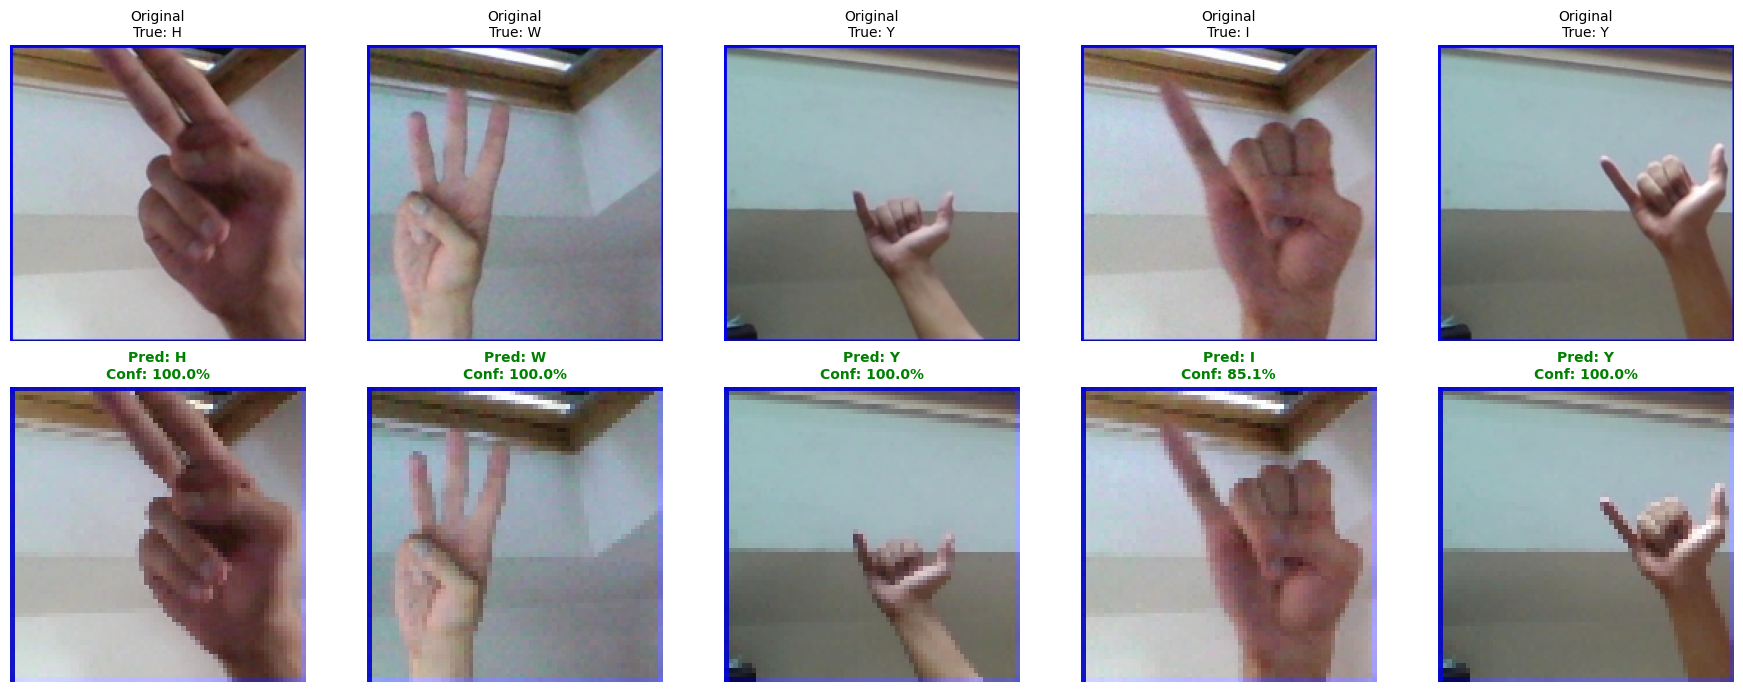


💡 WHAT TO LOOK FOR:
----------------------------------------------------------------------
✓ High confidence (>90%) = Model is sure
✓ Low confidence (<70%) = Model confused, check:
  - Background noise
  - Hand position
  - Lighting conditions
  - Similar looking signs (e.g., M, N, S)


In [33]:
# Test the model on sample images to verify predictions
print("="*70)
print("TESTING MODEL PREDICTIONS")
print("="*70)

# Let's test on some training images to see confidence scores
import random

def test_predictions_with_backgrounds(data_dir, classes, model, num_samples=5):
    """Test predictions and show confidence scores"""

    fig, axes = plt.subplots(2, num_samples, figsize=(18, 7))

    for i in range(num_samples):
        # Pick random class
        class_name = random.choice(classes)
        class_path = os.path.join(data_dir, class_name)

        # Pick random image
        img_files = os.listdir(class_path)
        img_file = random.choice(img_files)
        img_path = os.path.join(class_path, img_file)

        # Load and display original
        img_original = plt.imread(img_path)
        axes[0, i].imshow(img_original)
        axes[0, i].set_title(f'Original\nTrue: {class_name}', fontsize=10)
        axes[0, i].axis('off')

        # Preprocess and predict
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (64, 64))
        img_normalized = img_resized / 255.0
        img_expanded = np.expand_dims(img_normalized, axis=0)

        # Get prediction
        prediction = model_improved.predict(img_expanded, verbose=0)
        predicted_idx = np.argmax(prediction)
        predicted_class = index_to_class[predicted_idx]
        confidence = prediction[0][predicted_idx] * 100

        # Get top 3 predictions
        top3_indices = np.argsort(prediction[0])[-3:][::-1]
        top3_classes = [index_to_class[idx] for idx in top3_indices]
        top3_conf = [prediction[0][idx]*100 for idx in top3_indices]

        # Display preprocessed with prediction
        axes[1, i].imshow(img_resized)
        color = 'green' if predicted_class == class_name else 'red'
        title = f'Pred: {predicted_class}\nConf: {confidence:.1f}%'
        axes[1, i].set_title(title, color=color, fontsize=10, fontweight='bold')
        axes[1, i].axis('off')

        # Print detailed results
        status = " CORRECT" if predicted_class == class_name else "❌ WRONG"
        print(f"\n{status} - True: {class_name}, Predicted: {predicted_class}")
        print(f"  Confidence: {confidence:.2f}%")
        print(f"  Top 3: {top3_classes[0]}({top3_conf[0]:.1f}%), {top3_classes[1]}({top3_conf[1]:.1f}%), {top3_classes[2]}({top3_conf[2]:.1f}%)")

    plt.tight_layout()
    plt.show()

print("\n Testing random samples from training data:")
print("-"*70)
test_predictions_with_backgrounds(train_dir, train_classes, model_improved, num_samples=5)

print("\n" + "="*70)
print(" WHAT TO LOOK FOR:")
print("-"*70)
print("✓ High confidence (>90%) = Model is sure")
print("✓ Low confidence (<70%) = Model confused, check:")
print("  - Background noise")
print("  - Hand position")
print("  - Lighting conditions")
print("  - Similar looking signs (e.g., M, N, S)")
print("="*70)

In [45]:

# Print summary
print("\n" + "="*70)
print(" DETAILED COMPARISON TABLE")
print("="*70)
print(f"{'Metric':<25} {'Baseline CNN':<20} {'Improved CNN':<20} {'Change':<15}")
print("-"*70)
print(f"{'Training Accuracy':<25} {train_acc[0]:<20.2f} {train_acc[1]:<20.2f} {train_acc[1]-train_acc[0]:+.2f}%")
print(f"{'Validation Accuracy':<25} {val_acc[0]:<20.2f} {val_acc[1]:<20.2f} {val_acc[1]-val_acc[0]:+.2f}% ")
print(f"{'Test Accuracy':<25} {test_acc[0]:<20.2f} {test_acc[1]:<20.2f} {test_acc[1]-test_acc[0]:+.2f}%")
print(f"{'Training Loss':<25} {train_loss[0]:<20.4f} {train_loss[1]:<20.4f} {train_loss[1]-train_loss[0]:+.4f}")
print(f"{'Validation Loss':<25} {val_loss[0]:<20.4f} {val_loss[1]:<20.4f} {val_loss[1]-val_loss[0]:+.4f}")
print(f"{'Overfitting Gap':<25} {overfitting_gap[0]:<20.2f} {overfitting_gap[1]:<20.2f} {overfitting_gap[1]-overfitting_gap[0]:+.2f}%")
print("="*70)


 DETAILED COMPARISON TABLE
Metric                    Baseline CNN         Improved CNN         Change         
----------------------------------------------------------------------
Training Accuracy         98.76                93.46                -5.30%
Validation Accuracy       82.95                94.15                +11.20% 
Test Accuracy             100.00               100.00               +0.00%
Training Loss             0.0390               0.5551               +0.5161
Validation Loss           0.9277               0.5365               -0.3912
Overfitting Gap           15.81                -0.69                -16.50%


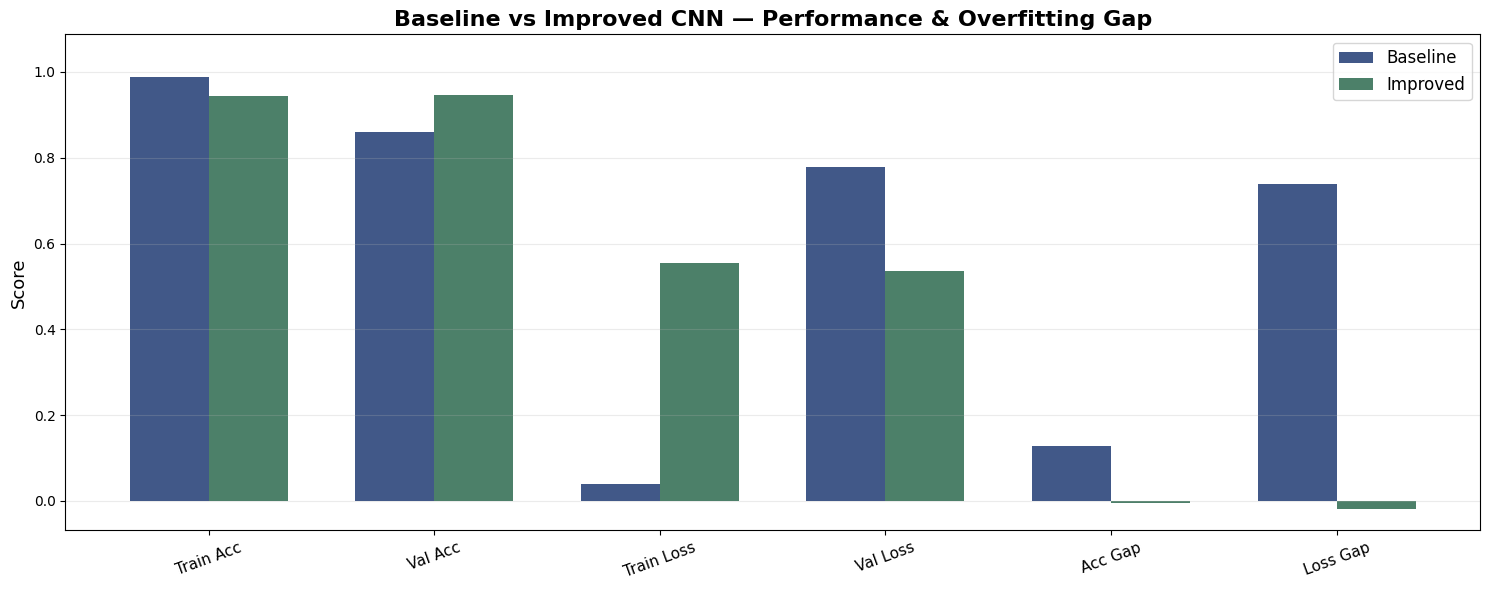

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Extract last-epoch values
baseline_train_acc = history.history['accuracy'][-1]
baseline_val_acc = history.history['val_accuracy'][-1]
baseline_train_loss = history.history['loss'][-1]
baseline_val_loss = history.history['val_loss'][-1]

improved_train_acc = history_improved.history['accuracy'][-1]
improved_val_acc = history_improved.history['val_accuracy'][-1]
improved_train_loss = history_improved.history['loss'][-1]
improved_val_loss = history_improved.history['val_loss'][-1]

# Overfitting gaps
baseline_gap_acc = baseline_train_acc - baseline_val_acc
baseline_gap_loss = baseline_val_loss - baseline_train_loss

improved_gap_acc = improved_train_acc - improved_val_acc
improved_gap_loss = improved_val_loss - improved_train_loss

# Labels
metrics = [
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss",
    "Acc Gap",
    "Loss Gap"
]

baseline_values = [
    baseline_train_acc,
    baseline_val_acc,
    baseline_train_loss,
    baseline_val_loss,
    baseline_gap_acc,
    baseline_gap_loss
]

improved_values = [
    improved_train_acc,
    improved_val_acc,
    improved_train_loss,
    improved_val_loss,
    improved_gap_acc,
    improved_gap_loss
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(15,6))
plt.title("Baseline vs Improved CNN — Performance & Overfitting Gap",
          fontsize=16, fontweight='bold')

# Professional colors
baseline_color = "#1f3b73"   # navy
improved_color = "#2d6a4f"   # dark green

# Plot bars
plt.bar(x - width/2, baseline_values, width,
        label='Baseline', color=baseline_color, alpha=0.85)

plt.bar(x + width/2, improved_values, width,
        label='Improved', color=improved_color, alpha=0.85)

plt.xticks(x, metrics, fontsize=11, rotation=20)
plt.ylabel("Score", fontsize=13)

# Set y-limits cleanly
plt.ylim(
    min(baseline_values + improved_values) - 0.05,
    max(baseline_values + improved_values) + 0.1
)

plt.grid(axis='y', alpha=0.25)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
